### Feature Engineering for Categorical Variables

Categorical features are everywhere such as the city a customer lives in, the product category they bought, their education level. Machine learning models require numbers, so we have to convert these labels into numeric representations. The challenge is doing this conversion without accidentally introducing a false ordering or giving the model misleading information.

Choosing the right encoding strategy is not just a technical detail as it can make a meaningful difference to model performance, especially for high-cardinality categories.

**In this notebook we will cover:**
1. Understanding nominal vs ordinal, and low vs high cardinality
2. Label Encoding and why it can be dangerous for nominal features
3. One-Hot Encoding - the standard approach
4. Target Mean Encoding with an important leakage discussion
5. Frequency Encoding
6. The hashing trick for very high cardinality
7. Handling unseen categories and rare values

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.feature_extraction import FeatureHasher
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

In [3]:
# Synthetic e-commerce customer dataset
n = 1000
np.random.seed(42)

cities     = ['New York', 'London', 'Berlin', 'Tokyo', 'Paris', 'Sydney',
               'Mumbai', 'Toronto', 'Dubai', 'Singapore']
categories = ['Electronics', 'Clothing', 'Food', 'Books']
sizes      = ['S', 'M', 'L', 'XL']
genders    = ['Male', 'Female', 'Non-binary']

# Some cities have higher churn rates (to make target encoding meaningful)
city_churn_prob = {
    'New York': 0.45, 'London': 0.35, 'Berlin': 0.25,
    'Tokyo': 0.20, 'Paris': 0.30, 'Sydney': 0.40,
    'Mumbai': 0.55, 'Toronto': 0.30, 'Dubai': 0.50, 'Singapore': 0.20}

city_col = np.random.choice(cities, n)
churn = np.array([np.random.binomial(1, city_churn_prob[c]) for c in city_col])

In [5]:
df = pd.DataFrame({
    'customer_id':      range(1, n+1),
    'city':             city_col,
    'product_category': np.random.choice(categories, n),
    'size':             np.random.choice(sizes, n),
    'gender':           np.random.choice(genders, n),
    'purchase_amount':  np.random.exponential(100, n),
    'churn':            churn,
})

In [7]:
df.head()

,customer_id,city,product_category,size,gender,purchase_amount,churn
0,1,Mumbai,Books,S,Male,89.933091,1
1,2,Tokyo,Electronics,M,Male,5.482373,0
2,3,Toronto,Books,S,Female,60.653718,0
3,4,Paris,Electronics,M,Non-binary,112.327278,0
4,5,Mumbai,Food,S,Non-binary,113.175018,0


In [9]:
df.shape

(1000, 7)

In [11]:
print(f'Churn rate: {df["churn"].mean():.2%}')

Churn rate: 35.10%


We have 1,000 customer records with four categorical columns. `product_category` has only 4 unique values, so easy to encode. `city` has 10, still manageable. `size` is ordinal (S < M < L < XL) and `gender` has 3 values. Each of these needs a different encoding approach, and understanding why is the main lesson of this notebook.

### Nominal vs Ordinal, Low vs High Cardinality

Before choosing an encoding method, you need to answer two questions about each categorical column.

**First: does the order matter?** A city name like 'Paris' is not greater or lesser than 'Tokyo', we call these *nominal* categories. But T-shirt size has a very clear order: S < M < L < XL. We call these *ordinal* categories. Treating a nominal column as if it had an order (by assigning integer codes 0, 1, 2...) is one of the most common mistakes in feature engineering.

**Second: how many unique values does it have?** A column with 3-4 unique values has *low cardinality*. One-hot encoding is straightforward and suitable options since you'll only add a few new columns. A column with hundreds or thousands of unique values has *high cardinality*. One-hot encoding becomes impractical (a zip code column could add 50,000 columns!), and you need smarter approaches.

Let's look at the cardinality of our columns.

Cardinality (unique values per column):
  city                :   10 unique values
  product_category    :    4 unique values
  size                :    4 unique values
  gender              :    3 unique values


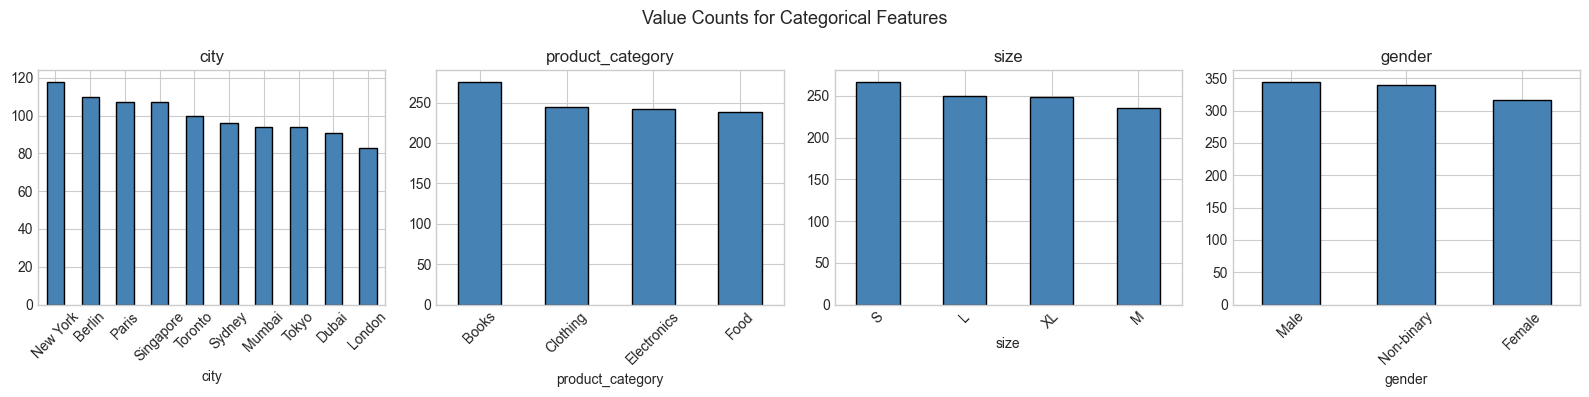

In [15]:
# Cardinality of each categorical column
cat_cols = ['city', 'product_category', 'size', 'gender']

print('Cardinality (unique values per column):')
for col in cat_cols:
    print(f'  {col:<20}: {df[col].nunique():>4} unique values')

# Visualize value counts
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Value Counts for Categorical Features', fontsize=13)
plt.tight_layout()
plt.show()

`product_category` with 4 unique values and `gender` with 3 are clearly low cardinality which one-hot encoding can handle well enough but `city` with 10 unique values is on borderline. In a real dataset, if 'city' represented US zip codes with 40,000 unique values, one-hot encoding would be out of the question.

### Label Encoding : Handle with Care

The simplest encoding is to assign each category an integer: Paris → 0, Berlin → 1, Tokyo → 2. This is called label encoding, and it takes one line of code.

The danger is subtle. When you encode 'Paris' as 0 and 'Tokyo' as 2, you've told the model that Tokyo is twice as much as Paris. A linear model will treat the difference between Berlin (1) and Tokyo (2) the same as the difference between Paris (0) and Berlin (1). That relationship is completely made up since cities don't have a numeric order.

**The one case where label encoding is correct** is for genuinely ordinal features. Shirt size S < M < L < XL has a real order, and we want to preserve it. Let's see both cases.

In [23]:
# Label encoding for nominal feature (city) — WRONG approach, shown for education
le = LabelEncoder()
city_encoded = le.fit_transform(df['city'])

print('Label encoding for city:')

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
for city, code in sorted(mapping.items()):
    print(f'  {city:<12} → {code}')
print('Model may think Berlin (0) and Dubai (3) are "closer" than Berlin and Singapore!')

Label encoding for city:
  Berlin       → 0
  Dubai        → 1
  London       → 2
  Mumbai       → 3
  New York     → 4
  Paris        → 5
  Singapore    → 6
  Sydney       → 7
  Tokyo        → 8
  Toronto      → 9
Model may think Berlin (0) and Dubai (3) are "closer" than Berlin and Singapore!


The warning at the bottom says it all. By encoding Berlin as 0, Dubai as 3, and Singapore as 9 (or whatever the sorted order happens to be), we've implied that Dubai is halfway between Berlin and Singapore. A linear model will take that implication seriously. For nominal categories, this is harmful misinformation.

In [26]:
# Correct way for nominal category encoding: Manual mapping
size_order = {'S': 0, 'M': 1, 'L': 2, 'XL': 3}
df['size_encoded'] = df['size'].map(size_order)

print('Manual ordinal encoding for size (ORDER is meaningful):')
print(df[['size', 'size_encoded']].drop_duplicates().sort_values('size_encoded'))

# sklearn OrdinalEncoder with explicit category order
oe = OrdinalEncoder(categories=[['S', 'M', 'L', 'XL']])
df['size_ordinal'] = oe.fit_transform(df[['size']]).astype(int)

print('\nsklearn OrdinalEncoder preserves the same order:')
df[['size', 'size_ordinal']].drop_duplicates().sort_values('size_ordinal')

Manual ordinal encoding for size (ORDER is meaningful):
  size  size_encoded
0    S             0
1    M             1
7    L             2
6   XL             3

sklearn OrdinalEncoder preserves the same order:


,size,size_ordinal
0,S,0
1,M,1
7,L,2
6,XL,3


For size, ordinal encoding is exactly right. S=0, M=1, L=2, XL=3 now correctly reflect the order. A model can learn "XL customers order more fabric" and that relationship will be meaningful. Always specify the category order explicitly when using OrdinalEncoder, don't let sklearn guess.

### One-Hot Encoding : The Standard for Nominal Features

One-hot encoding creates a new binary column for each unique category value. If a row has `city = 'Paris'`, then the `city_Paris` column gets a 1 and all other city columns get a 0. There's no implied ordering as each city is simply present or absent in its own column. This is the right approach for nominal low-cardinality features.

The main disadvantage is dimensionality: 10 cities create 10 new columns; 10,000 zip codes create 10,000. Beyond that, there's a subtler issue called the **dummy variable trap**. With n categories, you only need n−1 binary columns. If `city_Paris = 0` and `city_Berlin = 0`, the model already knows the city must be Tokyo and having a separate `city_Tokyo` column adds no information, just a perfectly collinear column. Linear models can have numerical instability when their features are perfectly collinear. Using `drop='first'` in OneHotEncoder removes one column automatically.

In [36]:
# pandas get_dummies
ohe_pandas = pd.get_dummies(df['product_category'], prefix='cat', drop_first=True)
ohe_pandas.head(6)

,cat_Clothing,cat_Electronics,cat_Food
0,False,False,False
1,False,True,False
2,False,False,False
3,False,True,False
4,False,False,True
5,False,False,True


In [38]:
# sklearn OneHotEncoder (preferred for pipelines)
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
city_ohe = ohe.fit_transform(df[['city']])

city_ohe_df = pd.DataFrame(city_ohe, columns=ohe.get_feature_names_out(['city']))
print('sklearn OneHotEncoder (city, drop=first):')
city_ohe_df.head(6)

sklearn OneHotEncoder (city, drop=first):


,city_Dubai,city_London,city_Mumbai,city_New York,city_Paris,city_Singapore,city_Sydney,city_Tokyo,city_Toronto
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


We started with one city column and ended with 9 binary columns (one was dropped to avoid the dummy trap). Each row has exactly one 1 and eight 0s. The model now knows which city each customer is from without any implied ordering, that's exactly what we want for a nominal feature.

### Target Mean Encoding : Powerful but Requires Discipline

For high-cardinality nominal features, one-hot encoding creates too many columns. Target mean encoding is a popular alternative: replace each category value with the mean of the target for that category. If customers from New York churn at a rate of 45%, then every row where `city = 'New York'` gets replaced with `0.45`.

This is powerful because it directly encodes the relationship between the category and the target and gives the model a single number that carries a lot of predictive signal. It also keeps the column count at exactly one, regardless of how many cities there are.

**The critical risk is data leakage.** If you compute city churn rates using the *entire dataset* before splitting into train and test, then your test rows contributed to the encoding statistics. The model has indirectly "seen" test data during training. This inflates your evaluation metrics and creates models that underperform in production.

The safe approach: compute means only on the training set, then apply those means to the test set.

In [42]:
X = df.drop('churn', axis=1)
y = df['churn']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# Data Leakage: compute means on FULL dataset (includes test rows)
leaky_map = df.groupby('city')['churn'].mean()
df['city_target_leaky'] = df['city'].map(leaky_map)

# No Data leakage: compute means ONLY on training data
safe_map = pd.concat([X_tr, y_tr], axis=1).groupby('city')['churn'].mean()
X_tr['city_target_safe'] = X_tr['city'].map(safe_map)
X_te['city_target_safe'] = X_te['city'].map(safe_map)  # uses training means only

print('City → Target Mean (from training data):')
print(safe_map.sort_values(ascending=False).round(3))

print('\nTrue churn rates (for verification):')
print({k: round(v, 3) for k, v in city_churn_prob.items()})

City → Target Mean (from training data):
city
Mumbai       0.607
Dubai        0.589
New York     0.474
London       0.409
Paris        0.341
Sydney       0.314
Berlin       0.304
Toronto      0.211
Singapore    0.202
Tokyo        0.120
Name: churn, dtype: float64

True churn rates (for verification):
{'New York': 0.45, 'London': 0.35, 'Berlin': 0.25, 'Tokyo': 0.2, 'Paris': 0.3, 'Sydney': 0.4, 'Mumbai': 0.55, 'Toronto': 0.3, 'Dubai': 0.5, 'Singapore': 0.2}


### Frequency Encoding : A Safe Alternative

Frequency encoding replaces each category with how often it appears in the dataset. A customer from 'New York' (the most common city in our data) gets encoded as a high number; a customer from 'London' (the least common) gets a low number.

This is useful when the frequency itself is meaningful, a product from a very popular category might behave differently from one in a niche category. And unlike target encoding, frequency encoding uses no information from the target column, so there's no leakage risk.

The disadvantage is that it can assign the same frequency to two very different categories if they happen to appear equally often.

In [49]:
# Frequency encoding — compute from training set, apply to both train and test
freq_map = X_tr['city'].value_counts() / len(X_tr)

X_tr = X_tr.copy()
X_te = X_te.copy()
X_tr['city_freq'] = X_tr['city'].map(freq_map)
X_te['city_freq'] = X_te['city'].map(freq_map).fillna(0)  # fill unseen with 0

print('Frequency encoding for city (from training data):')
freq_map.round(3).sort_values(ascending=False)

Frequency encoding for city (from training data):


city
New York     0.119
Berlin       0.115
Paris        0.106
Mumbai       0.105
Singapore    0.105
Toronto      0.095
Tokyo        0.094
Dubai        0.091
Sydney       0.088
London       0.082
Name: count, dtype: float64

### The Hashing Trick for Very High Cardinality

Imagine you have a column with 500,000 unique user IDs. One-hot encoding would create half a million columns. Target encoding needs enough rows per category to compute a reliable mean and with rare user IDs, you'd have one row per category and the encoding would be meaningless noise.

The hashing trick maps each category to one of a fixed number of bins (say, 32) using a hash function. No matter how many unique values you have, the output always has exactly 32 columns. The trade-off is **collisions** since two different categories might hash to the same bin, mixing their signals together. In practice, if you use enough bins, collisions are rare and the model can still learn.

This technique powers large-scale recommendation systems and click-through rate prediction where you might have billions of unique item IDs.

In [53]:
# Simulate very high cardinality feature (product URLs)
np.random.seed(42)
n_products = 10000
sample_products = [f'product_{i}' for i in np.random.randint(0, n_products, n)]

# Manual hashing: hash to 32 bins
n_bins = 32
product_hashed = [hash(p) % n_bins for p in sample_products]

print(f'Original: {len(set(sample_products))} unique product IDs')
print(f'After hashing to {n_bins} bins:')
print(pd.Series(product_hashed).value_counts().sort_index().head(10))

Original: 949 unique product IDs
After hashing to 32 bins:
0    29
1    30
2    32
3    27
4    34
5    23
6    24
7    28
8    31
9    35
Name: count, dtype: int64


### Handling Unseen and Rare Categories

Two situations will catch you in production if you're not prepared.

**Unseen categories:** Your model trained on cities including 'New York' and 'Tokyo'. Now a new customer from 'Dubai' arrives, a city the model never saw. Without preparation, your encoder will throw an error or produce garbage. The fix is `handle_unknown='ignore'` in sklearn's OneHotEncoder, which returns all-zero rows for unknown categories, effectively saying "this category is not one we recognise" and letting the model work with that neutral signal.

**Rare categories:** A category that appears only once or twice provides almost no statistical signal and makes your encoding unstable. The fix is to group rare categories (below, say, 5% frequency) into a single 'Other' bucket. This reduces cardinality and makes the remaining categories more reliable.

In [58]:
# Handling unseen categories with sklearn
ohe_safe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_safe.fit(X_tr[['city']])

# Test data with a never-seen-before city
test_with_new_city = pd.DataFrame({'city': ['New York', 'Atlantis', 'Tokyo']})
encoded = ohe_safe.transform(test_with_new_city)

result_df = pd.DataFrame(encoded, columns=ohe_safe.get_feature_names_out())
result_df.index = test_with_new_city['city'].values

print('Encoding with handle_unknown="ignore" (Atlantis → all zeros):')
result_df

Encoding with handle_unknown="ignore" (Atlantis → all zeros):


,city_Berlin,city_Dubai,city_London,city_Mumbai,city_New York,city_Paris,city_Singapore,city_Sydney,city_Tokyo,city_Toronto
New York,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Atlantis,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Tokyo,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [66]:
# Grouping rare categories into 'Other'
# Simulate a high-cardinality column where some values are rare
np.random.seed(42)
products_raw = np.random.choice(['Laptop', 'Phone', 'Tablet', 'Watch', 'Earbuds', 'Keyboard', 'Mouse', 'Monitor', 'Charger', 'Case'], 
                                n, p=[0.30, 0.25, 0.15, 0.10, 0.05, 0.04, 0.04, 0.03, 0.02, 0.02])

df_rare = pd.DataFrame({'product': products_raw})

print('Raw value counts:')
print(df_rare['product'].value_counts())

# Group categories below 5% frequency into 'Other'
freq = df_rare['product'].value_counts(normalize=True)
rare_categories = freq[freq < 0.05].index
df_rare['product_grouped'] = df_rare['product'].where(~df_rare['product'].isin(rare_categories), other='Other')

print('\nAfter grouping rare (<5%) into Other:')
print(df_rare['product_grouped'].value_counts())
print(f'\nColumn cardinality reduced effectively from {df_rare["product"].nunique()} to {df_rare["product_grouped"].nunique()}')

Raw value counts:
product
Laptop      319
Phone       240
Tablet      153
Watch        89
Mouse        53
Earbuds      46
Keyboard     32
Monitor      30
Charger      20
Case         18
Name: count, dtype: int64

After grouping rare (<5%) into Other:
product_grouped
Laptop    319
Phone     240
Tablet    153
Other     146
Watch      89
Mouse      53
Name: count, dtype: int64

Column cardinality reduced effectively from 10 to 6


### <font color='green'>Key things to remember from this notebook</font>

Always distinguish nominal from ordinal before encoding since using the wrong encoding for nominal data silently gives your model false information. For nominal low-cardinality features, one-hot encoding with `drop='first'` is the safe default. For high-cardinality features, target encoding is powerful but must be computed from training data only to avoid leakage. Always use `handle_unknown='ignore'` in OneHotEncoder to survive production data gracefully.